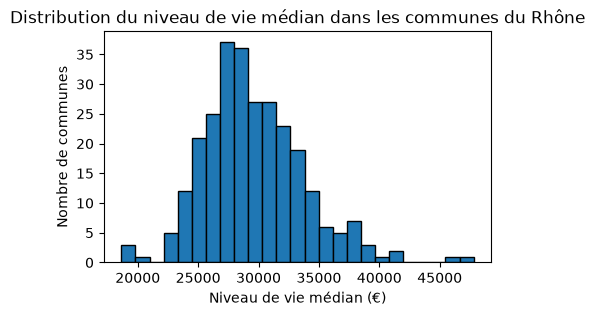

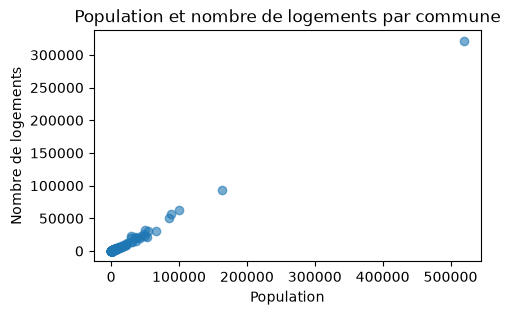

In [1]:
import matplotlib.pyplot as plt
import pandas as pd  

# dataviz apres preprocessing ( pivot + creation features)
df_insee_final = pd.read_csv("../data/processed/insee_comparateur_territoires_69.csv")

# Distribution du niveau de vie médian
plt.figure(figsize=(5, 3))
plt.hist(df_insee_final["niveau_vie_median"].dropna(), bins=25, edgecolor="black")
plt.title("Distribution du niveau de vie médian dans les communes du Rhône")
plt.xlabel("Niveau de vie médian (€)")
plt.ylabel("Nombre de communes")
plt.show()

# Relation entre population et nombre de logements
plt.figure(figsize=(5, 3))
plt.scatter(df_insee_final["population"], df_insee_final["nb_logements"], alpha=0.6)
plt.title("Population et nombre de logements par commune")
plt.xlabel("Population")
plt.ylabel("Nombre de logements")

plt.show()

**Interprétation Le niveau de vie médian :**  
Le niveau de vie médian des communes du Rhône se concentre principalement entre **25 000 € et 35 000 €**. La majorité des communes se situe autour de **27 000 € à 30 000 €**. Quelques communes présentent des niveaux de vie plus élevés, supérieurs à **40 000 €**. Cette variable pourra être étudiée par la suite afin d'évaluer sa relation avec le prix au m².



**Interprétation population vs nombre de logements:**  
Le graphique montre une forte relation positive entre la population et le nombre de logements : les communes les plus peuplées disposent généralement d'un nombre de logements plus important. Quelques communes se distinguent nettement par des valeurs très élevées. Cette relation montre également que ces deux variables apportent une information assez proche sur la taille des communes.

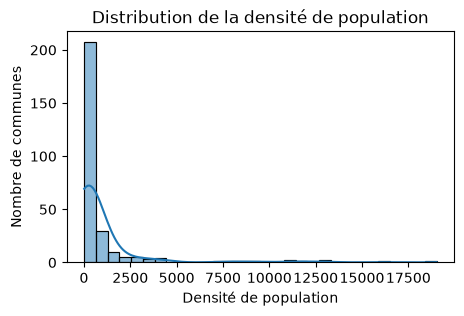

In [2]:
# Graphe sur la variable Feature densité de population

import seaborn as sns
plt.figure(figsize=(5, 3))

sns.histplot(data=df_insee_final, x="densite_population", bins=30, kde=True)

plt.title("Distribution de la densité de population")
plt.xlabel("Densité de population")
plt.ylabel("Nombre de communes")
plt.show()

### Interprétation

La distribution de la densité de population est fortement asymétrique à droite. La majorité des communes présentent une densité relativement faible, tandis que quelques communes se distinguent par des densités beaucoup plus élevées.

Cette feature permet ainsi de différencier les communes peu denses des zones fortement urbanisées. Elle peut donc apporter une information pertinente pour l’estimation immobilière, le niveau d’urbanisation pouvant être associé aux différences de prix au m². Cette relation devra toutefois être vérifiée après la jointure avec les données DVF.

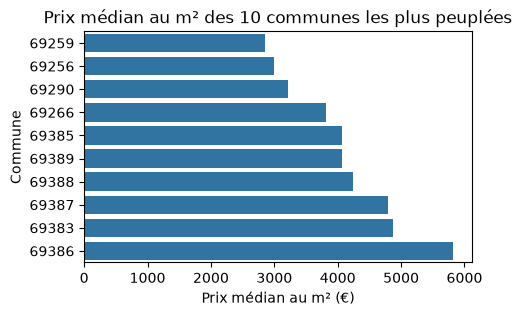

In [3]:
# Graphe APRES JOINTURE AVEC DVF (Dataset DVF + INSEE)

dvf_insee = pd.read_csv("../data/processed/dvf_insee_enrichi.csv", dtype={"code_commune": "string"})
# 10 communes les plus peuplées
communes = (
    dvf_insee.groupby("code_commune")
    .agg(population=("population", "first"), prix_median_m2=("prix_m2", "median"))
    .nlargest(10, "population")
    .sort_values("prix_median_m2")
)

plt.figure(figsize=(5, 3))
sns.barplot(data=communes, x="prix_median_m2", y=communes.index)
plt.title("Prix médian au m² des 10 communes les plus peuplées")
plt.xlabel("Prix médian au m² (€)")
plt.ylabel("Commune")
plt.show()

### Interprétation

Le graphique montre que les 10 communes les plus peuplées présentent des niveaux de prix immobiliers assez différents, avec des prix médians au m² allant d’environ 2 900 à 5 800 €/m².

Ainsi, une population importante ne correspond pas nécessairement à un prix immobilier plus élevé. Ce résultat montre l’intérêt de combiner les données socio-démographiques de l’INSEE avec les données immobilières DVF afin de mieux caractériser les différences entre les communes.